# Notebook 2: Speech and text representations in ECoG

This notebook has two parts.

First, it partially replicates the Whisper analysis in Shimizu et al. Second, it compares Whisper with Qwen representations from the aligned transcript.

The main question is:

> After speech and timing are controlled, how much neural variance is shared with acoustic, phonetic and syntactic features?

Five depths are used for each model.

## 0. Setup and load data


In [1]:
!pip install himalaya nilearn --quiet

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FEAT = Path("/kaggle/input/datasets/delhialli/podcast-ecog-features")
ROOT = Path("/kaggle/input/datasets/delhialli/podcast-ecog-dataset/kaggle/working/ds005574")


def load_array(name):
    return np.load(FEAT / f"{name}.npy", allow_pickle=True)

Y = load_array("Y_all").astype(np.float32)
t = load_array("t")
col_subject = load_array("col_subject")
col_channel = load_array("col_channel")

interp = {
    name: load_array(name)
    for name in ["mel", "gbfb", "speech", "phonetic", "syntactic"]
}
timing = load_array("timing")
whisper = load_array("whisper")
qwen = load_array("qwen")

print("Y:", Y.shape)
print("Whisper:", whisper.shape)
print("Qwen:", qwen.shape)
print("interpretable features:", list(interp))
print("timing controls:", timing.shape)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.0/90.0 kB 4.9 MB/s eta 0:00:00
Y: (7200, 1268)
Whisper: (7200, 33, 1280)
Qwen: (7200, 29, 3584)
interpretable features: ['mel', 'gbfb', 'speech', 'phonetic', 'syntactic']
timing controls: (7200, 3)


## 1. Encoding model

Every feature set uses the same five contiguous outer folds. PCA and standardization are fitted on the outer training data.

Prepared arrays are cached. This avoids running the same PCA many times.


In [2]:
from himalaya.backend import set_backend
from himalaya.ridge import GroupRidgeCV
from himalaya.scoring import r2_score, correlation_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

backend = set_backend("torch_cuda")
ALPHAS = np.logspace(0, 3, 20)
N_FOLDS = 5
N_ITER = 20
PCA_VARIANCE = 0.95
PCA_THRESHOLD = 100


def contiguous_folds(n_samples, n_folds=N_FOLDS):
    edges = np.linspace(0, n_samples, n_folds + 1).astype(int)
    all_rows = np.arange(n_samples)
    for fold in range(n_folds):
        test = np.arange(edges[fold], edges[fold + 1])
        train = np.setdiff1d(all_rows, test)
        yield fold, train, test


_prepared = {}


def prepare_group(name, array, fold, train, test):
    key = (name, fold)
    if key in _prepared:
        return _prepared[key]

    train_array = array[train]
    test_array = array[test]

    if array.shape[1] > PCA_THRESHOLD:
        pca = PCA(PCA_VARIANCE, svd_solver="full").fit(train_array)
        train_array = pca.transform(train_array)
        test_array = pca.transform(test_array)

    scaler = StandardScaler().fit(train_array)
    prepared = (
        scaler.transform(train_array).astype(np.float32),
        scaler.transform(test_array).astype(np.float32),
    )
    _prepared[key] = prepared
    return prepared


def fit_fold(groups, fold, train, test):
    train_parts = []
    test_parts = []
    group_labels = []

    for group_index, (name, array) in enumerate(groups.items()):
        train_array, test_array = prepare_group(name, array, fold, train, test)
        train_parts.append(train_array)
        test_parts.append(test_array)
        group_labels.extend([group_index] * train_array.shape[1])

    model = GroupRidgeCV(
        groups=np.asarray(group_labels),
        cv=4,
        random_state=0,
        solver_params={
            "alphas": ALPHAS,
            "n_iter": N_ITER,
            "progress_bar": False,
        },
    )
    model.fit(np.hstack(train_parts), Y[train])
    prediction = model.predict(np.hstack(test_parts))
    target = backend.asarray(Y[test])

    return (
        backend.to_numpy(r2_score(target, prediction)),
        backend.to_numpy(correlation_score(target, prediction)),
    )


def evaluate(groups):
    fold_results = [
        fit_fold(groups, fold, train, test)
        for fold, train, test in contiguous_folds(len(Y))
    ]
    r2_values, correlations = zip(*fold_results)
    return np.mean(r2_values, axis=0), np.mean(correlations, axis=0)

## 2. Variance partitioning

In [3]:
_results_cache = {}


def model_result(groups):
    key = tuple(sorted(groups))
    if key not in _results_cache:
        _results_cache[key] = evaluate(groups)
    return _results_cache[key]


def model_r2(groups):
    return np.clip(model_result(groups)[0], 0, None)


def model_correlation(groups):
    return model_result(groups)[1]


def partition(feature_a, feature_b, control=None):
    """Unique and shared held-out R² for two feature sets."""
    control = control or {}

    r2_a_control = model_r2({**feature_a, **control})
    r2_b_control = model_r2({**feature_b, **control})
    r2_all = model_r2({**feature_a, **feature_b, **control})
    r2_control = model_r2(control) if control else 0.0

    unique_a = np.clip(r2_all - r2_b_control, 0, None)
    unique_b = np.clip(r2_all - r2_a_control, 0, None)
    shared = np.clip(
        (r2_a_control - r2_control)
        + (r2_b_control - r2_control)
        - (r2_all - r2_control),
        0,
        None,
    )
    return unique_a, unique_b, shared


def total_ratio(numerator, denominator):
    total = denominator.sum()
    return float(numerator.sum() / total) if total > 0 else np.nan

## 3. Layer sweeps

The full interpretable set is used for the Whisper redundancy and unique-variance analysis.

The speech–text comparison uses absolute shared R². Speech probability and the timing block are controlled for every acoustic and linguistic feature.

In [4]:
WHISPER_LAYERS = [0, 8, 16, 24, 32]
QWEN_LAYERS = [0, 7, 14, 21, 28]
FEATURES = ["mel", "gbfb", "phonetic", "syntactic"]

overlap_control = {
    "speech": interp["speech"],
    "timing": timing,
}


def empty_results(include_whisper_terms=False):
    keys = ["layer", "r_model", "r_joint"]
    if include_whisper_terms:
        keys += ["redundancy", "unique"]
    keys += FEATURES
    keys += [f"{feature}_denom" for feature in FEATURES]
    return {key: [] for key in keys}


R = empty_results(include_whisper_terms=True)

for layer in WHISPER_LAYERS:
    model_group = {f"whisper_L{layer}": whisper[:, layer, :]}

    unique_model, _, shared_interp = partition(model_group, interp)
    R["redundancy"].append(total_ratio(shared_interp, model_r2(model_group)))
    R["unique"].append(float(unique_model.mean()))
    R["r_model"].append(float(model_correlation(model_group).mean()))
    R["r_joint"].append(float(model_correlation({**model_group, **interp}).mean()))

    for feature in FEATURES:
        _, _, shared = partition(
            model_group,
            {feature: interp[feature]},
            control=overlap_control,
        )
        feature_beyond_control = np.clip(
            model_r2({feature: interp[feature], **overlap_control})
            - model_r2(overlap_control),
            0,
            None,
        )
        R[feature].append(float(shared.mean()))
        R[f"{feature}_denom"].append(float(feature_beyond_control.mean()))

    R["layer"].append(layer / 32)
    print(
        f"Whisper L{layer:2d} | redundancy {R['redundancy'][-1]:.3f} | "
        f"unique {R['unique'][-1]:.5f} | r {R['r_model'][-1]:.3f}"
    )


Q = empty_results()

for layer in QWEN_LAYERS:
    model_group = {f"qwen_L{layer}": qwen[:, layer, :]}

    Q["r_model"].append(float(model_correlation(model_group).mean()))
    Q["r_joint"].append(float(model_correlation({**model_group, **interp}).mean()))

    for feature in FEATURES:
        _, _, shared = partition(
            model_group,
            {feature: interp[feature]},
            control=overlap_control,
        )
        feature_beyond_control = np.clip(
            model_r2({feature: interp[feature], **overlap_control})
            - model_r2(overlap_control),
            0,
            None,
        )
        Q[feature].append(float(shared.mean()))
        Q[f"{feature}_denom"].append(float(feature_beyond_control.mean()))

    Q["layer"].append(layer / 28)
    print(
        f"Qwen L{layer:2d} | mel shared {Q['mel'][-1]:.5f} | "
        f"syntax shared {Q['syntactic'][-1]:.5f} | r {Q['r_model'][-1]:.3f}"
    )

Whisper L 0 | redundancy 0.984 | unique 0.00049 | r 0.047


/usr/local/lib/python3.12/dist-packages/himalaya/ridge/_random_search.py:393: UserWarning: torch.linalg.svd: During SVD computation with the selected cusolver driver, batches 0 failed to converge. A more accurate method will be used to compute the SVD as a fallback. Check doc at https://pytorch.org/docs/stable/generated/torch.linalg.svd.html (Triggered internally at /pytorch/aten/src/ATen/native/cuda/linalg/BatchLinearAlgebraLib.cpp:701.)
  U, eigenvalues, Vt = backend.svd(Xtrain, full_matrices=False)


Whisper L 8 | redundancy 0.877 | unique 0.00241 | r 0.065
Whisper L16 | redundancy 0.828 | unique 0.00345 | r 0.065
Whisper L24 | redundancy 0.778 | unique 0.00468 | r 0.069
Whisper L32 | redundancy 0.739 | unique 0.00590 | r 0.074
Qwen L 0 | mel shared 0.00108 | syntax shared 0.00161 | r 0.033
Qwen L 7 | mel shared 0.00172 | syntax shared 0.00227 | r 0.042
Qwen L14 | mel shared 0.00186 | syntax shared 0.00232 | r 0.043
Qwen L21 | mel shared 0.00188 | syntax shared 0.00232 | r 0.045
Qwen L28 | mel shared 0.00183 | syntax shared 0.00223 | r 0.047


## 4. Figure 1: Whisper replication

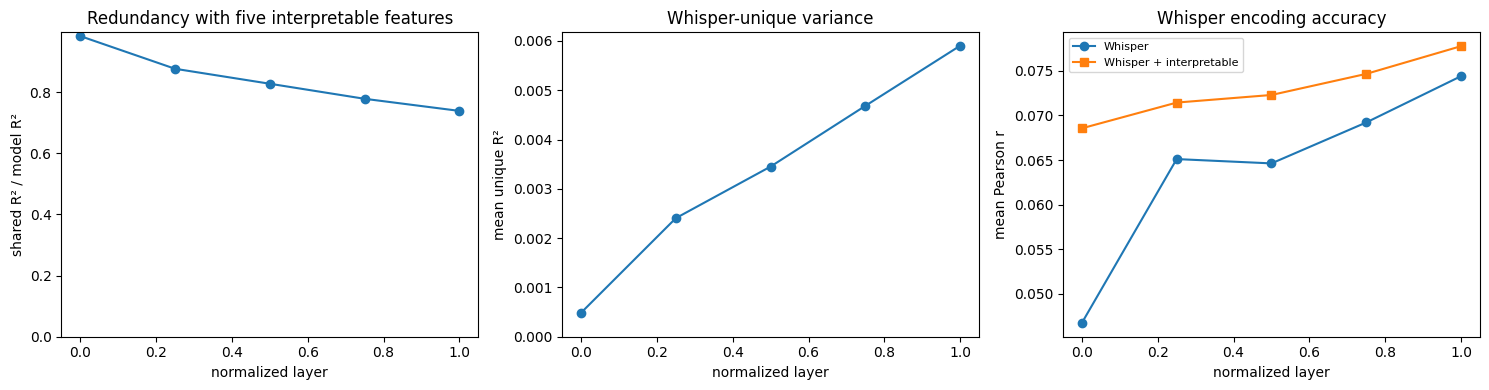

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(R["layer"], R["redundancy"], "o-")
axes[0].set(
    title="Redundancy with five interpretable features",
    xlabel="normalized layer",
    ylabel="shared R² / model R²",
)
axes[0].set_ylim(bottom=0)

axes[1].plot(R["layer"], R["unique"], "o-")
axes[1].set(
    title="Whisper-unique variance",
    xlabel="normalized layer",
    ylabel="mean unique R²",
)
axes[1].set_ylim(bottom=0)

axes[2].plot(R["layer"], R["r_model"], "o-", label="Whisper")
axes[2].plot(R["layer"], R["r_joint"], "s-", label="Whisper + interpretable")
axes[2].set(
    title="Whisper encoding accuracy",
    xlabel="normalized layer",
    ylabel="mean Pearson r",
)
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 5. Figure 2: Speech versus text

Absolute shared R² is shown here. All four features use the same speech and timing controls.

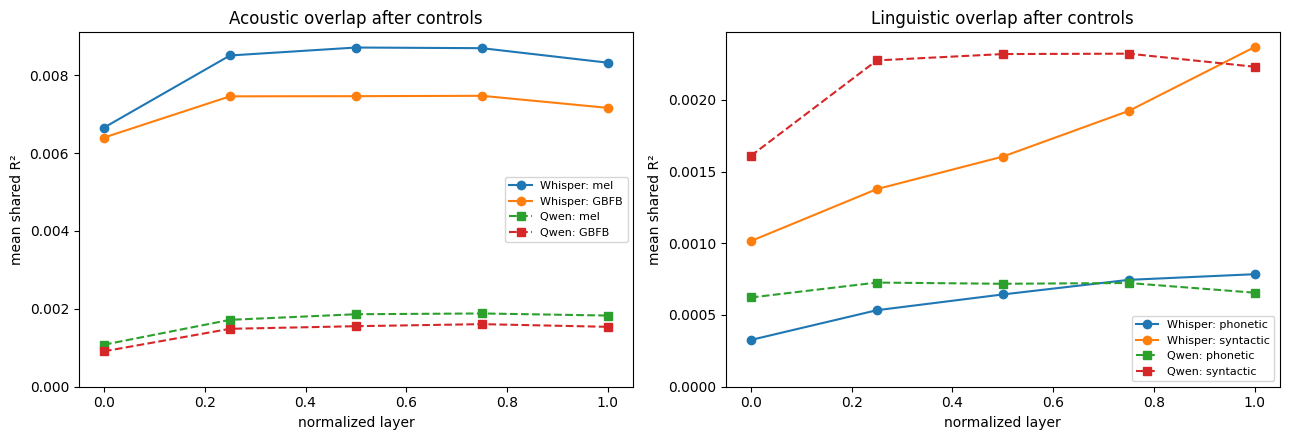

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for results, style, model_name in [
    (R, "o-", "Whisper"),
    (Q, "s--", "Qwen"),
]:
    axes[0].plot(results["layer"], results["mel"], style, label=f"{model_name}: mel")
    axes[0].plot(results["layer"], results["gbfb"], style, label=f"{model_name}: GBFB")

axes[0].set(
    title="Acoustic overlap after controls",
    xlabel="normalized layer",
    ylabel="mean shared R²",
)
axes[0].set_ylim(bottom=0)
axes[0].legend(fontsize=8)

for results, style, model_name in [
    (R, "o-", "Whisper"),
    (Q, "s--", "Qwen"),
]:
    axes[1].plot(results["layer"], results["phonetic"], style, label=f"{model_name}: phonetic")
    axes[1].plot(results["layer"], results["syntactic"], style, label=f"{model_name}: syntactic")

axes[1].set(
    title="Linguistic overlap after controls",
    xlabel="normalized layer",
    ylabel="mean shared R²",
)
axes[1].set_ylim(bottom=0)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 6. Figure 3: Qwen accuracy and participant check

The first panel shows Qwen alone and Qwen with the five interpretable features.

The second panel checks final-layer syntactic overlap for each participant.

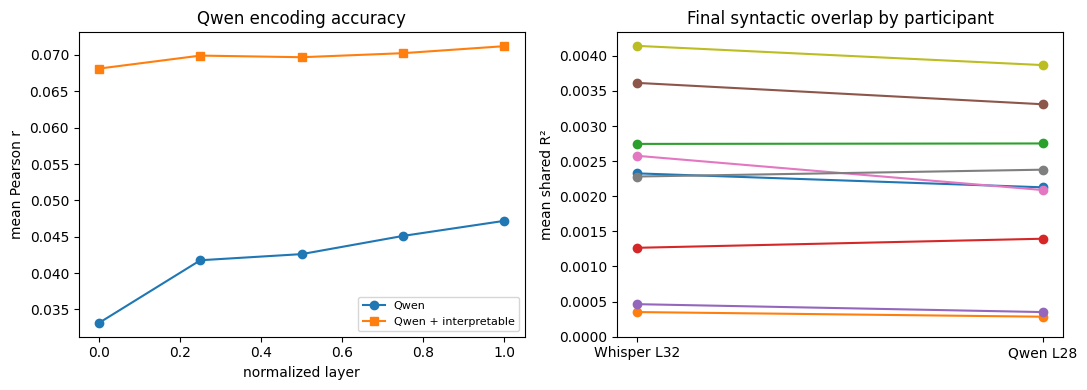

,participant,Whisper syntax shared R²,Qwen syntax shared R²
0,sub-01,0.002325,0.002127
1,sub-02,0.000351,0.000285
2,sub-03,0.002745,0.002751
3,sub-04,0.001266,0.001395
4,sub-05,0.000463,0.000351
5,sub-06,0.003614,0.003310
6,sub-07,0.002575,0.002088
7,sub-08,0.002281,0.002378
8,sub-09,0.004141,0.003867


In [7]:
whisper_final = {"whisper_L32": whisper[:, 32, :]}
qwen_final = {"qwen_L28": qwen[:, 28, :]}


_, _, final_syntax_whisper = partition(
    whisper_final,
    {"syntactic": interp["syntactic"]},
    control=overlap_control,
)
_, _, final_syntax_qwen = partition(
    qwen_final,
    {"syntactic": interp["syntactic"]},
    control=overlap_control,
)


subjects = sorted(np.unique(col_subject).tolist())
whisper_subject_syntax = np.array([
    final_syntax_whisper[col_subject == subject].mean()
    for subject in subjects
])
qwen_subject_syntax = np.array([
    final_syntax_qwen[col_subject == subject].mean()
    for subject in subjects
])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(Q["layer"], Q["r_model"], "o-", label="Qwen")
axes[0].plot(Q["layer"], Q["r_joint"], "s-", label="Qwen + interpretable")
axes[0].set(
    title="Qwen encoding accuracy",
    xlabel="normalized layer",
    ylabel="mean Pearson r",
)
axes[0].legend(fontsize=8)

for i, subject in enumerate(subjects):
    axes[1].plot(
        [0, 1],
        [whisper_subject_syntax[i], qwen_subject_syntax[i]],
        "o-",
    )
axes[1].set_xticks([0, 1], ["Whisper L32", "Qwen L28"])
axes[1].set(
    title="Final syntactic overlap by participant",
    ylabel="mean shared R²",
)
axes[1].set_ylim(bottom=0)

plt.tight_layout()
plt.show()

subject_table = pd.DataFrame({
    "participant": subjects,
    "Whisper syntax shared R²": whisper_subject_syntax,
    "Qwen syntax shared R²": qwen_subject_syntax,
})
display(subject_table.round(6))

## 7. Electrode maps

In [8]:
from nilearn import plotting

coordinates = {}
for subject in subjects:
    table = pd.read_csv(
        ROOT / subject / "ieeg" / f"{subject}_space-MNI152NLin2009aSym_electrodes.tsv",
        sep="\t",
    )
    for _, row in table.iterrows():
        coordinates[(subject, row["name"])] = (row["x"], row["y"], row["z"])

xyz = np.asarray([
    coordinates.get((subject, channel), (np.nan, np.nan, np.nan))
    for subject, channel in zip(col_subject, col_channel)
], dtype=float)
has_coordinate = ~np.isnan(xyz).any(axis=1)

print("electrodes with coordinates:", int(has_coordinate.sum()), "/", len(has_coordinate))

electrodes with coordinates: 1268 / 1268


### Whisper variance beyond the five interpretable features

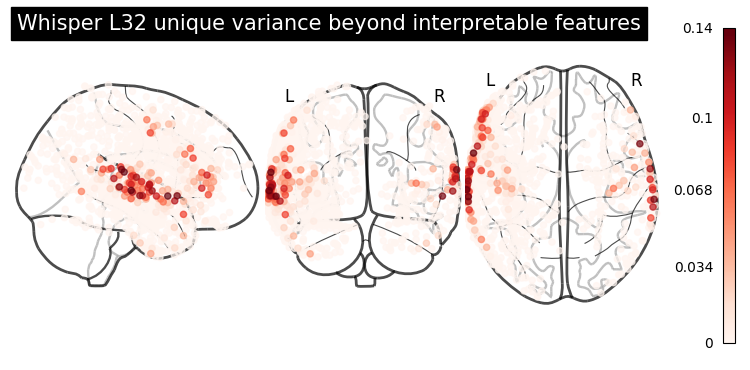

In [9]:
unique_whisper_interp, _, _ = partition(whisper_final, interp)

positive = unique_whisper_interp[has_coordinate]
positive = positive[positive > 0]
if len(positive):
    vmax = np.percentile(positive, 99)
    values = unique_whisper_interp[has_coordinate]
    positions = xyz[has_coordinate]
    order = np.argsort(values)
    plotting.plot_markers(
        values[order],
        positions[order],
        node_cmap="Reds",
        node_vmin=0,
        node_vmax=vmax,
        node_size=20,
        title="Whisper L32 unique variance beyond interpretable features",
    )
    plotting.show()

### Qwen variance not explained by the five interpretable feature sets

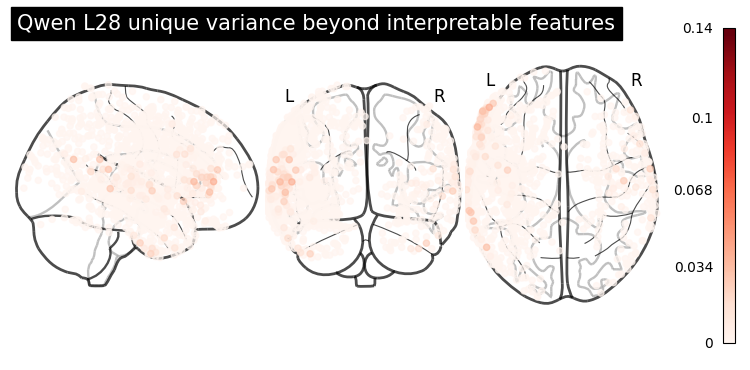

In [14]:
unique_qwen_interp, _, _ = partition(qwen_final, interp)

values = unique_qwen_interp[has_coordinate]
positions = xyz[has_coordinate]
order = np.argsort(values)

plotting.plot_markers(
    values[order],
    positions[order],
    node_cmap="Reds",
    node_vmin=0,
    node_vmax=vmax,  # Same scale as the Whisper map
    node_size=20,
    title="Qwen L28 unique variance beyond interpretable features",
)
plotting.show()

### Preferred layer per electrode

This uses only the five sampled depths.

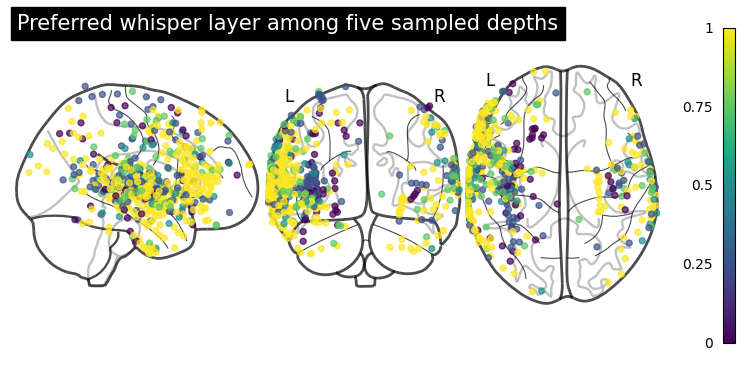

whisper : 542 electrodes above r = 0.05


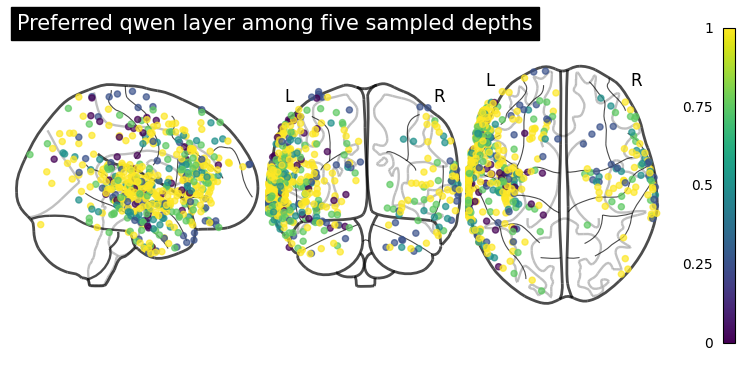

qwen : 520 electrodes above r = 0.05


In [10]:
def preferred_layer_map(features, layers, model_name):
    correlations = np.stack([
        model_correlation({f"{model_name}_L{layer}": features[:, layer, :]})
        for layer in layers
    ])
    best_index = correlations.argmax(axis=0)
    best_layer = np.asarray(layers)[best_index]
    normalized_layer = best_layer / (features.shape[1] - 1)
    peak_correlation = correlations.max(axis=0)

    shown = has_coordinate & (peak_correlation > 0.05)
    if shown.any():
        plotting.plot_markers(
            normalized_layer[shown],
            xyz[shown],
            node_cmap="viridis",
            node_vmin=0,
            node_vmax=1,
            title=f"Preferred {model_name} layer among five sampled depths",
        )
        plotting.show()

    print(model_name, ":", int(shown.sum()), "electrodes above r = 0.05")
    return normalized_layer, peak_correlation

preferred_whisper, peak_whisper = preferred_layer_map(
    whisper, WHISPER_LAYERS, "whisper"
)
preferred_qwen, peak_qwen = preferred_layer_map(
    qwen, QWEN_LAYERS, "qwen"
)

## 8. Summary

In [11]:
print("WHISPER REPLICATION")
print("  redundancy, first -> last:", round(R["redundancy"][0], 3), "->", round(R["redundancy"][-1], 3))
print("  model-unique, first -> last:", round(R["unique"][0], 5), "->", round(R["unique"][-1], 5))
print("  accuracy, first -> last:", round(R["r_model"][0], 3), "->", round(R["r_model"][-1], 3))

rows = []
for model_name, results in [("Whisper L32", R), ("Qwen L28", Q)]:
    for feature in FEATURES:
        rows.append({
            "model": model_name,
            "feature": feature,
            "shared R²": results[feature][-1],
            "feature R² after controls": results[f"{feature}_denom"][-1],
        })

print("\nFINAL-LAYER CONTROLLED OVERLAP")
display(pd.DataFrame(rows).round(6))

WHISPER REPLICATION
  redundancy, first -> last: 0.984 -> 0.739
  model-unique, first -> last: 0.00049 -> 0.0059
  accuracy, first -> last: 0.047 -> 0.074

FINAL-LAYER CONTROLLED OVERLAP


,model,feature,shared R²,feature R² after controls
0,Whisper L32,mel,0.008320,0.010047
1,Whisper L32,gbfb,0.007160,0.008821
2,Whisper L32,phonetic,0.000784,0.000756
3,Whisper L32,syntactic,0.002368,0.002342
4,Qwen L28,mel,0.001828,0.010047
5,Qwen L28,gbfb,0.001538,0.008821
6,Qwen L28,phonetic,0.000655,0.000756
7,Qwen L28,syntactic,0.002230,0.002342


## 9. Save results

In [15]:
RESULTS = Path("/kaggle/working/results")
RESULTS.mkdir(exist_ok=True)

with open(RESULTS / "results.json", "w") as file:
    json.dump({"whisper": R, "qwen": Q}, file, indent=2)

np.savez_compressed(
    RESULTS / "per_electrode.npz",
    final_syntax_shared_whisper=final_syntax_whisper,
    final_syntax_shared_qwen=final_syntax_qwen,
    unique_whisper_beyond_interp=unique_whisper_interp,
    unique_qwen_beyond_interp=unique_qwen_interp,
    preferred_layer_whisper=preferred_whisper,
    peak_r_whisper=peak_whisper,
    preferred_layer_qwen=preferred_qwen,
    peak_r_qwen=peak_qwen,
    xyz=xyz,
    has_coordinate=has_coordinate,
    col_subject=col_subject,
    col_channel=col_channel,
)

metadata = {
    "whisper_layers": WHISPER_LAYERS,
    "qwen_layers": QWEN_LAYERS,
    "overlap_statistic": "mean absolute shared held-out R2",
    "overlap_controls": [
        "speech_probability",
        "word_count_0.5s",
        "phoneme_count_0.5s",
        "time_since_word_offset_clipped_0.5s",
    ],
    "speech_presence": "EfficientAT mn20_as, 0.5 s window",
    "semantic_features": "not included",
    "final_layer_comparison": "Whisper L32 versus Qwen L28",
    "engine": {
        "outer_folds": N_FOLDS,
        "inner_folds": 4,
        "pca_variance": PCA_VARIANCE,
        "n_iter": N_ITER,
    },
}
with open(RESULTS / "run_meta.json", "w") as file:
    json.dump(metadata, file, indent=2)

print("saved:")
for path in sorted(RESULTS.iterdir()):
    print(" ", path.name)

saved:
  per_electrode.npz
  results.json
  run_meta.json


In [16]:
import shutil
from IPython.display import FileLink, display

zip_base = "/kaggle/working/encoding_results"
shutil.make_archive(zip_base, "zip", RESULTS)
print("archive size:", round(Path(zip_base + ".zip").stat().st_size / 1e6, 1), "MB")
display(FileLink("encoding_results.zip"))

archive size: 0.0 MB


/kaggle/working/encoding_results.zip